<a href="https://colab.research.google.com/github/MatiasHerrneder/bdm-2025/blob/main/TP04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Punto 1

In [2]:
def d_euclidea (x1, x2):
  return d_minkowski (x1, x2, 2)

def d_manhattan (x1, x2):
  return d_minkowski (x1, x2, 1)

def d_minkowski (x1, x2, p):
  c = 0
  for i in range(len(x1)):
    c += abs(x1[i] - x2[i])**p
  return c**(1/p)


In [4]:
p1 = [4,4]
p_list = [[8,2], [15,7], [2,9]]
print(d_euclidea([4,4], [8,2]))
print(d_manhattan([4,4], [15,7]))
print(d_minkowski([4,4], [2,9], 3))

4.47213595499958
14.0
5.104468722001463


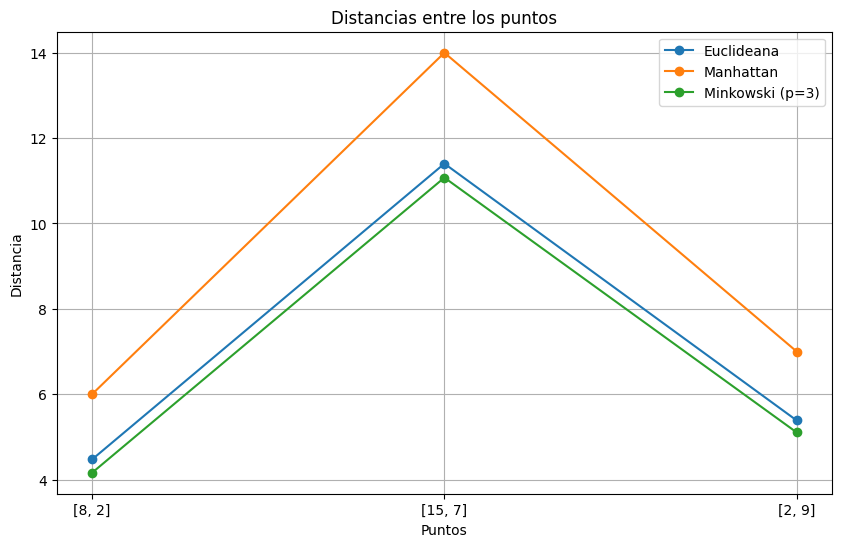

In [8]:
import matplotlib.pyplot as plt

euclideas = []
manhattans = []
minkowskis = []

for p in p_list:
  euclideas.append(d_euclidea(p1, p))
  manhattans.append(d_manhattan(p1, p))
  minkowskis.append(d_minkowski(p1, p, 3))

x_labels = [f"{p}" for i, p in enumerate(p_list)]

plt.figure(figsize=(10, 6))

plt.plot(x_labels, euclideas, marker='o', label='Euclideana')
plt.plot(x_labels, manhattans, marker='o', label='Manhattan')
plt.plot(x_labels, minkowskis, marker='o', label='Minkowski (p=3)')

plt.xlabel('Puntos')
plt.ylabel('Distancia')
plt.title('Distancias entre los puntos')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
import random
puntos = []
for i in range(100):
    puntos.append([random.randint(0, 20), random.randint(0, 20)])

p_euclidea = []
p_manhattan = []
p_minkowski = []

for p in puntos:
  c_eu = 0
  c_ma = 0
  c_mi = 0
  for p2 in puntos:
    c_eu += d_euclidea(p, p2)
    c_ma += d_manhattan(p, p2)
    c_mi += d_minkowski(p, p2, 3)
  p_euclidea.append(c_eu / 100)
  p_manhattan.append(c_ma / 100)
  p_minkowski.append(c_mi / 100)

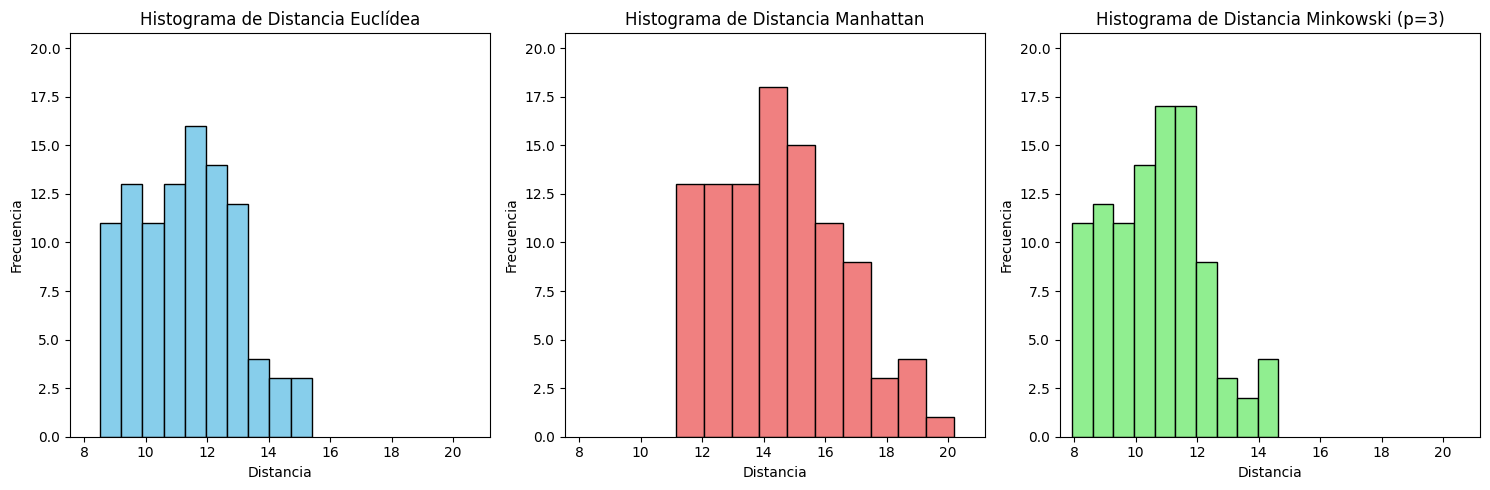

In [ ]:
import matplotlib.pyplot as plt

# Calculate overall min and max for distances to set common x-axis limits
all_distances = p_euclidea + p_manhattan + p_minkowski
min_dist = min(all_distances)
max_dist = max(all_distances)

plt.figure(figsize=(15, 5))

# Plot Euclídea
ax1 = plt.subplot(1, 3, 1)
plt.hist(p_euclidea, bins=10, color='skyblue', edgecolor='black')
plt.title('Histograma de Distancia Euclídea')
plt.xlabel('Distancia')
plt.ylabel('Frecuencia')

# Plot Manhattan
ax2 = plt.subplot(1, 3, 2)
plt.hist(p_manhattan, bins=10, color='lightcoral', edgecolor='black')
plt.title('Histograma de Distancia Manhattan')
plt.xlabel('Distancia')
plt.ylabel('Frecuencia')

# Plot Minkowski
ax3 = plt.subplot(1, 3, 3)
plt.hist(p_minkowski, bins=10, color='lightgreen', edgecolor='black')
plt.title('Histograma de Distancia Minkowski (p=3)')
plt.xlabel('Distancia')
plt.ylabel('Frecuencia')

# Determine global max frequency for y-axis across all subplots
max_freq_eu = ax1.get_ylim()[1]
max_freq_man = ax2.get_ylim()[1]
max_freq_min = ax3.get_ylim()[1]
global_max_freq = max(max_freq_eu, max_freq_man, max_freq_min)

# Set common x and y limits for all subplots
for ax in [ax1, ax2, ax3]:
    ax.set_xlim(min_dist * 0.95, max_dist * 1.05) # Add a small buffer to x-axis
    ax.set_ylim(0, global_max_freq * 1.1) # Add a small buffer to y-axis

plt.tight_layout()
plt.show()

# Punto 2

In [9]:
import pandas as pd

weather_data_string = '''#,PRONÓSTICO,TEMPERATURA,HUMEDAD,VIENTO
2,lluvioso,Frío,normal,fuertе
3,nublado,Frío,normal,fuertе
4,soleado,templado,alta,leve
5,soleado,Frío,normal,leve
6,lluvioso,templado,normal,leve
7,soleado,templado,normal,fuertе
8,nublado,templado,alta,fuertе
9,nublado,Calor,normal,leve
10,lluvioso,templado,alta,fuertе'''

from io import StringIO
df_weather = pd.read_csv(StringIO(weather_data_string), index_col=0)

csv_filename = 'datos_clima.csv'
df_weather.to_csv(csv_filename)

In [10]:
t1 = {
    'PRONÓSTICO': 'soleado',
    'TEMPERATURA': 'Frío',
    'HUMEDAD': 'alta',
    'VIENTO': 'leve'
}

distancias = []
for row in df_weather.itertuples():
  dif = 0
  dif += (row.PRONÓSTICO != t1['PRONÓSTICO']);
  dif += (row.TEMPERATURA != t1['TEMPERATURA']);
  dif += (row.HUMEDAD != t1['HUMEDAD']);
  dif += (row.VIENTO != t1['VIENTO']);

  distancias.append(dif/4)
  print(f"Fila {row.Index}: distancia = {(dif/4):.2f}")

Fila 2: distancia = 0.75
Fila 3: distancia = 0.75
Fila 4: distancia = 0.25
Fila 5: distancia = 0.25
Fila 6: distancia = 0.75
Fila 7: distancia = 0.75
Fila 8: distancia = 0.75
Fila 9: distancia = 0.75
Fila 10: distancia = 0.75


# Punto 3

In [42]:
def calcular_centroides(k, data, element_clusters):
  centroides = [[0 for _ in range(len(data[0]))] for _ in range(k)]
  counts = [0 for _ in range(k)]

  for i in range(len(data)):
    c = element_clusters[i]
    counts[c] += 1
    for j in range(len(data[0])):
      centroides[c][j] += data[i][j]

  for i in range(k):
    if counts[i] > 0:
      for j in range(len(data[0])):
        centroides[i][j] /= counts[i]

  return centroides

def k_means(k, iterations, data):
  # asignacion random
  element_clusters = []
  for i in range(len(data)):
    element_clusters.append(random.randint(0, k-1))
    # element_clusters.append(i % k)
  # calculo de centroides
  centroides = calcular_centroides(k, data, element_clusters)
  # resto de iteraciones
  print("Centroides:")
  print(centroides)
  for _ in range(iterations-1):
    # reasigno clusters
    for i in range(len(data)):
      dist = d_euclidea(data[i], centroides[0])
      element_clusters[i] = 0
      for j in range(1, k):
        n_dist = d_euclidea(data[i], centroides[j])
        if n_dist < dist:
          dist = n_dist
          element_clusters[i] = j
    # calculo de centroides
    centroides = calcular_centroides(k, data, element_clusters)
    print(centroides)
  return element_clusters



test_data = [[10,2],[2,3],[3,4], [2,12], [22,2]]
labels = k_means(2, 6, test_data)
print(labels)

Centroides:
[[4.666666666666667, 5.666666666666667], [12.5, 3.0]]
[[2.3333333333333335, 6.333333333333333], [16.0, 2.0]]
[[2.3333333333333335, 6.333333333333333], [16.0, 2.0]]
[[2.3333333333333335, 6.333333333333333], [16.0, 2.0]]
[[2.3333333333333335, 6.333333333333333], [16.0, 2.0]]
[[2.3333333333333335, 6.333333333333333], [16.0, 2.0]]
[1, 0, 0, 0, 1]


In [43]:
from sklearn.metrics import silhouette_score

# labels = k_means(2, 4, test_data)

# calculamos silueta
score = silhouette_score(test_data, labels)
print(f"Coeficiente de silueta promedio: {score:.3f}")


Coeficiente de silueta promedio: 0.396


# Punto 4

In [ ]:
import requests
from io import StringIO

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"
response = requests.get(url)
df = pd.read_csv(StringIO(response.text), header=None, sep=r'\s+')

print(df.head())
print(df.info())

       0      1       2      3      4      5      6  7
0  15.26  14.84  0.8710  5.763  3.312  2.221  5.220  1
1  14.88  14.57  0.8811  5.554  3.333  1.018  4.956  1
2  14.29  14.09  0.9050  5.291  3.337  2.699  4.825  1
3  13.84  13.94  0.8955  5.324  3.379  2.259  4.805  1
4  16.14  14.99  0.9034  5.658  3.562  1.355  5.175  1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       210 non-null    float64
 1   1       210 non-null    float64
 2   2       210 non-null    float64
 3   3       210 non-null    float64
 4   4       210 non-null    float64
 5   5       210 non-null    float64
 6   6       210 non-null    float64
 7   7       210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB
None


k=2: betweenss/totss=0.628, silueta=0.518
k=3: betweenss/totss=0.784, silueta=0.472
k=4: betweenss/totss=0.826, silueta=0.393
k=5: betweenss/totss=0.858, silueta=0.367
k=6: betweenss/totss=0.872, silueta=0.362
k=7: betweenss/totss=0.895, silueta=0.370
k=8: betweenss/totss=0.900, silueta=0.338
k=9: betweenss/totss=0.914, silueta=0.333


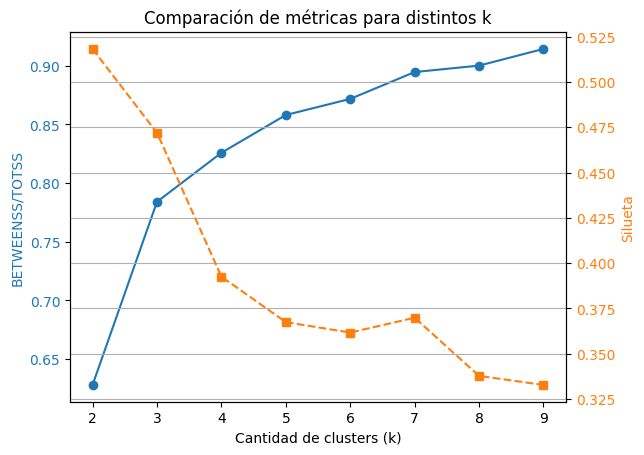

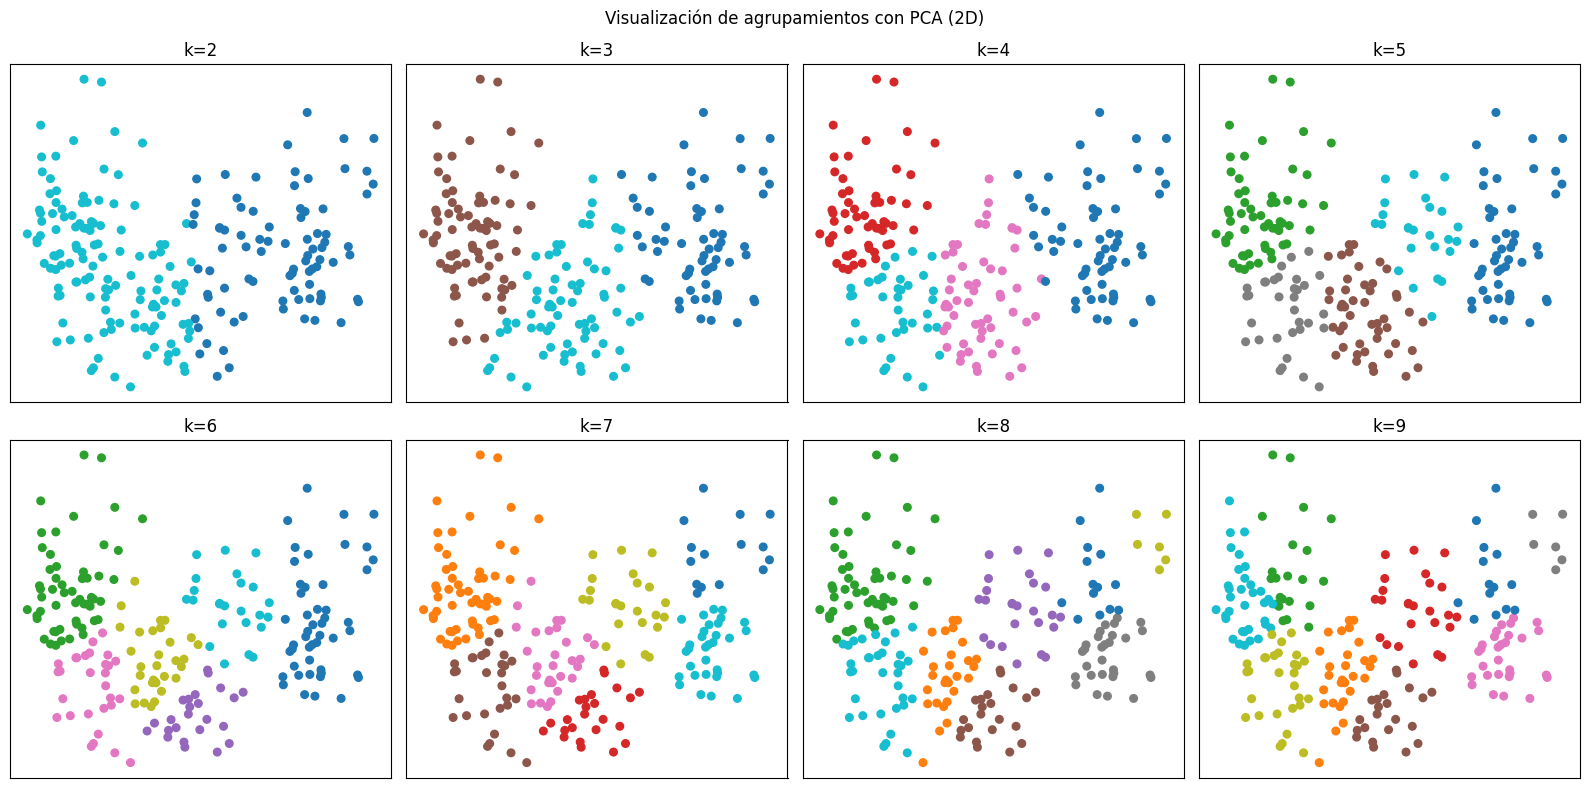

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import numpy as np

X = df.iloc[:, :-1].values

overall_mean = np.mean(X, axis=0)
totss = np.sum((X - overall_mean)**2)

resultados = []
centroides = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)

    withinss = kmeans.inertia_
    betweenss = totss - withinss
    ratio = betweenss / totss
    sil_score = silhouette_score(X, kmeans.labels_)
    centroides.append(kmeans.cluster_centers_)

    resultados.append((k, ratio, sil_score))
    print(f"k={k}: betweenss/totss={ratio:.3f}, silueta={sil_score:.3f}")

# --- Graficar métricas ---
ks = [r[0] for r in resultados]
ratios = [r[1] for r in resultados]
sil_scores = [r[2] for r in resultados]

fig, ax1 = plt.subplots()
ax1.plot(ks, ratios, 'o-', label='BETWEENSS/TOTSS', color='tab:blue')
ax1.set_xlabel('Cantidad de clusters (k)')
ax1.set_ylabel('BETWEENSS/TOTSS', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(ks, sil_scores, 's--', label='Coeficiente de Silueta', color='tab:orange')
ax2.set_ylabel('Silueta', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Comparación de métricas para distintos k')
plt.grid(True)
plt.show()

# PCA para graficar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, k in enumerate(range(2, 10)):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=30)
    axes[i].set_title(f"k={k}")
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.suptitle("Visualización de agrupamientos con PCA (2D)")
plt.tight_layout()
plt.show()


           0          1         2         3         4         5         6
0  18.721803  16.297377  0.885087  6.208934  3.722672  3.603590  6.066098
1  11.964416  13.274805  0.852200  5.229286  2.872922  4.759740  5.088519
2  14.648472  14.460417  0.879167  5.563778  3.277903  2.648933  5.192319


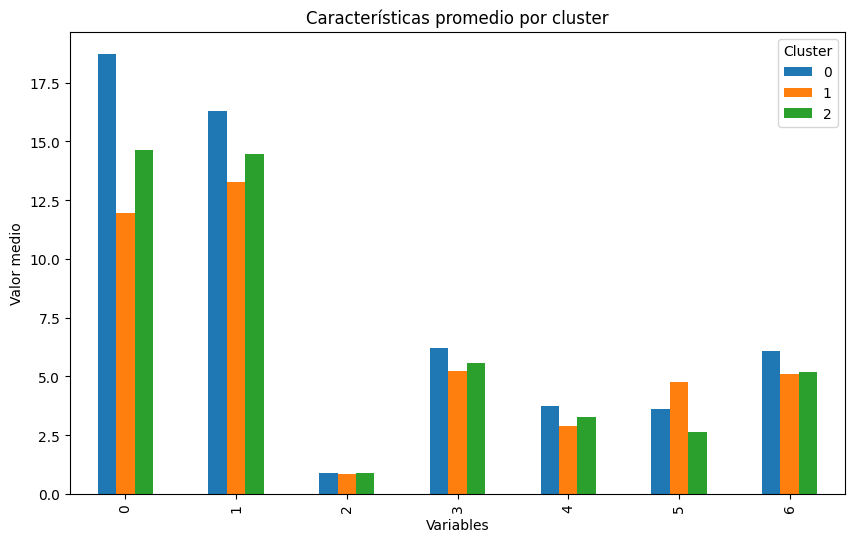

In [ ]:
cant_clusters = 3

print(pd.DataFrame(centroides[cant_clusters-2], columns=df.columns[:-1]))

centroides_df = pd.DataFrame(centroides[cant_clusters-2], columns=df.columns[:-1])

centroides_df.T.plot(kind='bar', figsize=(10,6))
plt.title("Características promedio por cluster")
plt.ylabel("Valor medio")
plt.xlabel("Variables")
plt.legend(title="Cluster")
plt.show()

# Punto 5

In [ ]:
url = "https://raw.githubusercontent.com/bdm-unlu/2025/main/TPs/TP04/abandono_cuantitativo.csv"

df_ab = pd.read_csv(url, sep=";")
print(df_ab.head())
df_ab.info()

   horas_trabajadas  masculino  edad_ingreso  colegio_publico  argentino  \
0                 0          0            22                1          1   
1                 0          0            21                1          1   
2                 0          0            54                1          1   
3                 0          0            28                1          1   
4                24          0            28                1          1   

   activo_primer_anio  activo_segundo_anio  anios_en_unlu  aprobadas_1er_anio  \
0                   1                    0            1.0                   0   
1                   0                    1            2.0                   0   
2                   1                    0            3.0                   0   
3                   1                    0            3.0                   0   
4                   1                    1            2.0                   0   

   anios_cursados  ...  c_libres_1er_anio  c_regulares_1

In [ ]:
from sklearn.impute import KNNImputer

print("Conteo de valores faltantes por columna:")
print(df_ab.isnull().sum()[df_ab.isnull().sum() > 0])

imputer = KNNImputer(n_neighbors=3)
df_ab = pd.DataFrame(imputer.fit_transform(df_ab), columns=df_ab.columns)


Conteo de valores faltantes por columna:
anios_en_unlu    8
dtype: int64


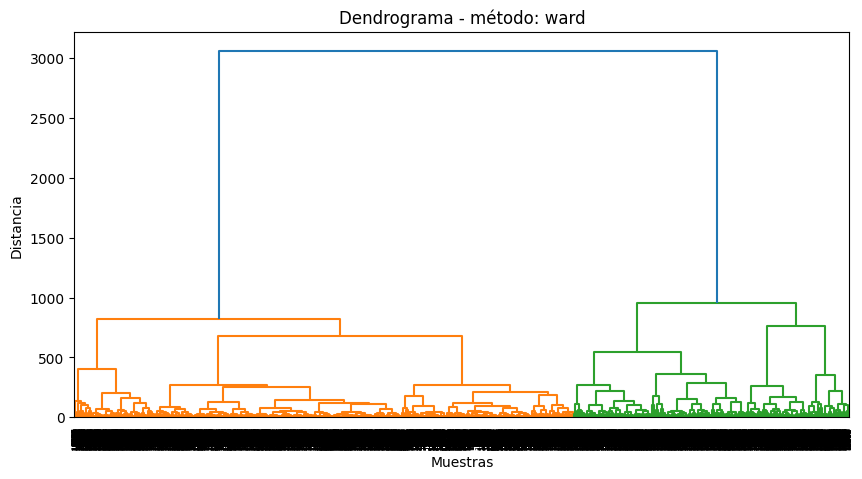

k=2: betweenss/totss=0.636, silueta=0.571
k=3: betweenss/totss=0.697, silueta=0.464
k=4: betweenss/totss=0.742, silueta=0.350
k=5: betweenss/totss=0.781, silueta=0.356
k=6: betweenss/totss=0.812, silueta=0.297
k=7: betweenss/totss=0.832, silueta=0.268
k=8: betweenss/totss=0.844, silueta=0.260
k=9: betweenss/totss=0.853, silueta=0.257


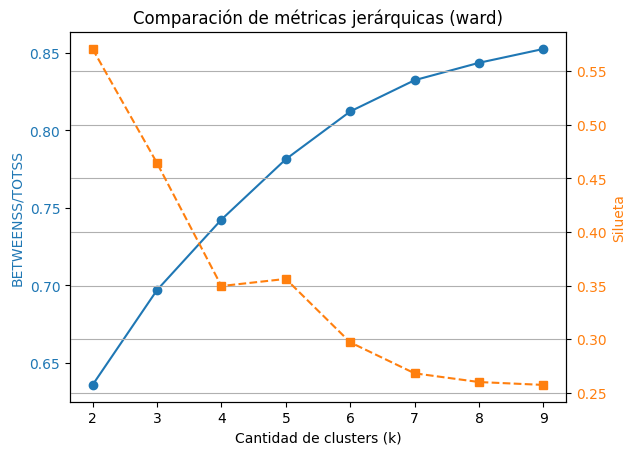

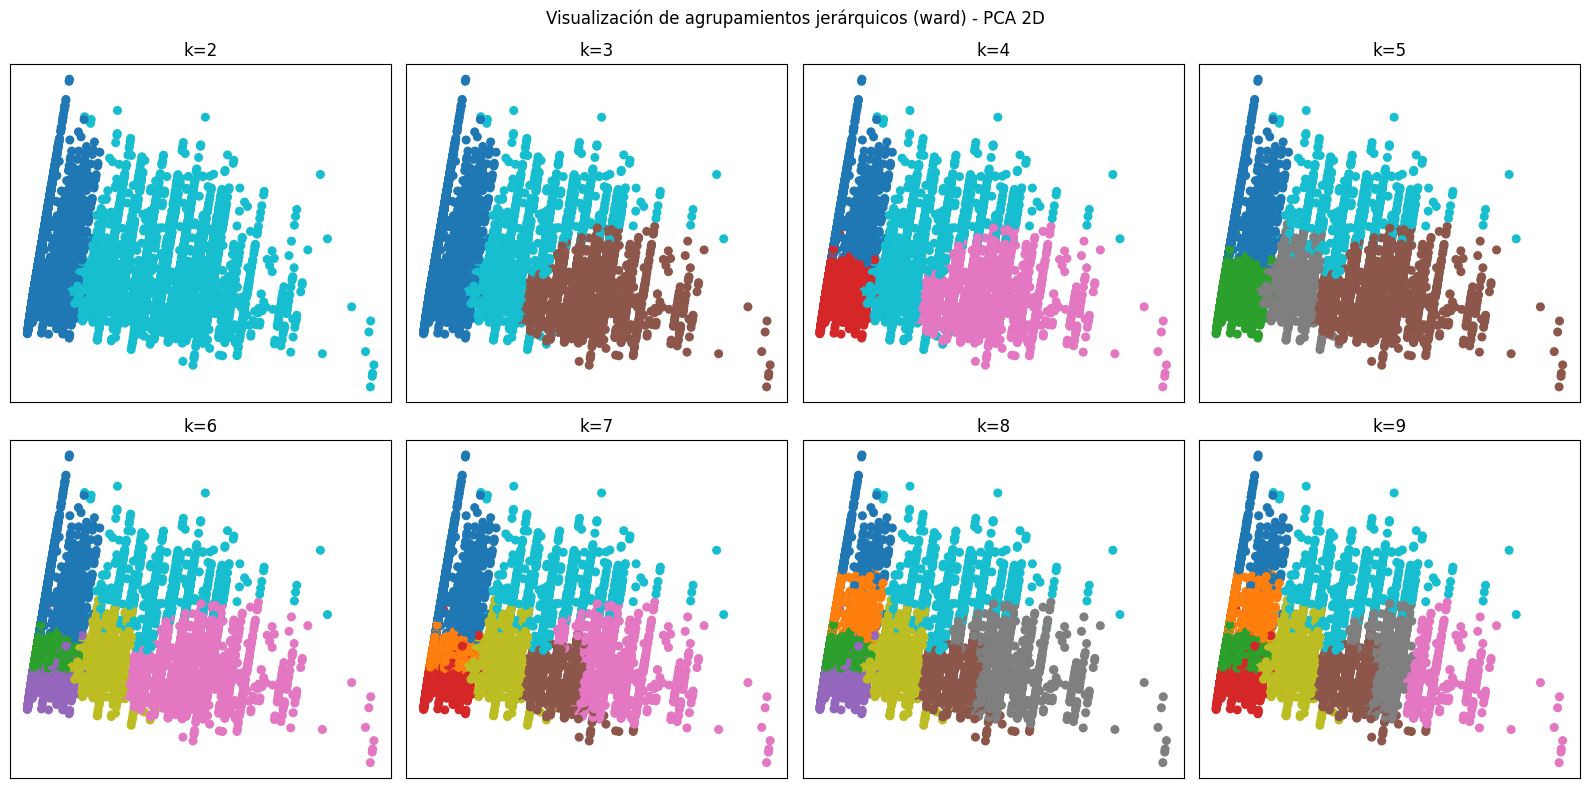

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

X = df_ab.iloc[:, :-1].values

linkage_method = 'ward'
Z = linkage(X, method=linkage_method)

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title(f"Dendrograma - método: {linkage_method}")
plt.xlabel("Muestras")
plt.ylabel("Distancia")
plt.show()

overall_mean = np.mean(X, axis=0)
totss = np.sum((X - overall_mean)**2)

resultados = []
for k in range(2, 10):
    labels = fcluster(Z, k, criterion='maxclust')

    withinss = sum(np.sum((X[labels == i] - np.mean(X[labels == i], axis=0))**2)
                   for i in np.unique(labels))
    betweenss = totss - withinss
    ratio = betweenss / totss

    sil = silhouette_score(X, labels)

    resultados.append((k, ratio, sil))
    print(f"k={k}: betweenss/totss={ratio:.3f}, silueta={sil:.3f}")

ks = [r[0] for r in resultados]
ratios = [r[1] for r in resultados]
sil_scores = [r[2] for r in resultados]

fig, ax1 = plt.subplots()
ax1.plot(ks, ratios, 'o-', color='tab:blue')
ax1.set_xlabel('Cantidad de clusters (k)')
ax1.set_ylabel('BETWEENSS/TOTSS', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(ks, sil_scores, 's--', color='tab:orange')
ax2.set_ylabel('Silueta', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title(f"Comparación de métricas jerárquicas ({linkage_method})")
plt.grid(True)
plt.show()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, k in enumerate(range(2, 10)):
    labels = fcluster(Z, k, criterion='maxclust')
    axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=30)
    axes[i].set_title(f"k={k}")
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.suptitle(f"Visualización de agrupamientos jerárquicos ({linkage_method}) - PCA 2D")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

X = df_ab.iloc[:, :-1].values

linkage_methods = ['ward', 'centroid', 'complete', 'average', 'single']
k_values = list(range(3, 6))

overall_mean = np.mean(X, axis=0)
totss = np.sum((X - overall_mean)**2)

# Resultados almacenados
resultados = []

for method in linkage_methods:
    print(f"\n=== Evaluando linkage: {method} ===")

    Z = linkage(X, method=method)

    for k in k_values:
        labels = fcluster(Z, k, criterion='maxclust')

        withinss = sum(np.sum((X[labels == i] - np.mean(X[labels == i], axis=0))**2)
                       for i in np.unique(labels))
        betweenss = totss - withinss
        ratio = betweenss / totss

        sil = silhouette_score(X, labels)

        resultados.append({
            'method': method,
            'k': k,
            'betweenss/totss': ratio,
            'silhouette': sil
        })

        print(f"  k={k}: ratio={ratio:.3f}, silueta={sil:.3f}")



=== Evaluando linkage: ward ===
  k=3: ratio=0.697, silueta=0.464
  k=4: ratio=0.742, silueta=0.350
  k=5: ratio=0.781, silueta=0.356

=== Evaluando linkage: centroid ===
  k=3: ratio=0.036, silueta=0.467
  k=4: ratio=0.650, silueta=0.524
  k=5: ratio=0.675, silueta=0.493

=== Evaluando linkage: complete ===
  k=3: ratio=0.255, silueta=0.307
  k=4: ratio=0.258, silueta=0.303
  k=5: ratio=0.701, silueta=0.464

=== Evaluando linkage: average ===
  k=3: ratio=0.019, silueta=0.389
  k=4: ratio=0.020, silueta=0.371
  k=5: ratio=0.650, silueta=0.532

=== Evaluando linkage: single ===
  k=3: ratio=0.001, silueta=0.569
  k=4: ratio=0.009, silueta=0.569
  k=5: ratio=0.009, silueta=0.553


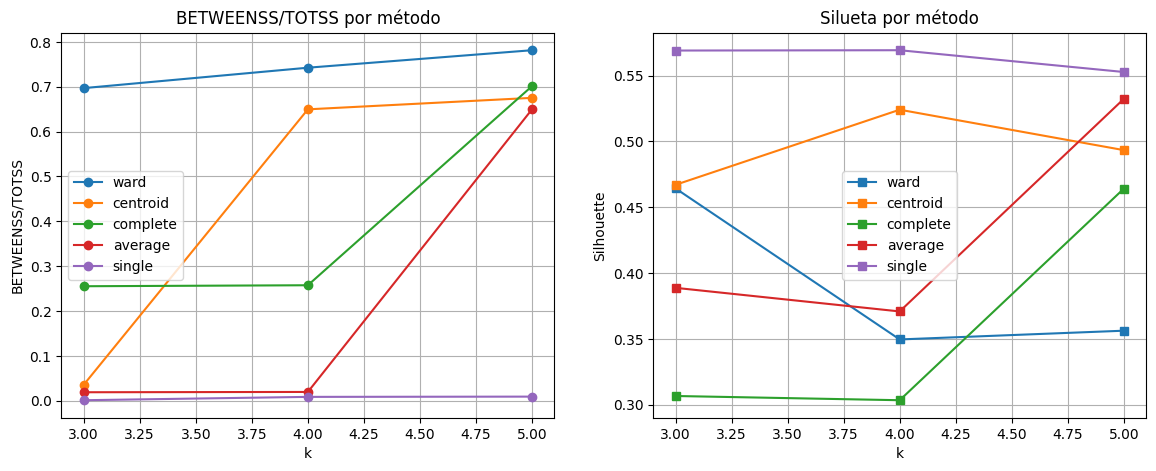

In [ ]:
import pandas as pd

df_res = pd.DataFrame(resultados)
df_res

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for method in linkage_methods:
    temp = df_res[df_res['method'] == method]
    axes[0].plot(temp['k'], temp['betweenss/totss'], marker='o', label=method)

axes[0].set_title("BETWEENSS/TOTSS por método")
axes[0].set_xlabel("k")
axes[0].set_ylabel("BETWEENSS/TOTSS")
axes[0].legend()
axes[0].grid(True)

for method in linkage_methods:
    temp = df_res[df_res['method'] == method]
    axes[1].plot(temp['k'], temp['silhouette'], marker='s', label=method)

axes[1].set_title("Silueta por método")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
axes[1].legend()
axes[1].grid(True)

plt.show()


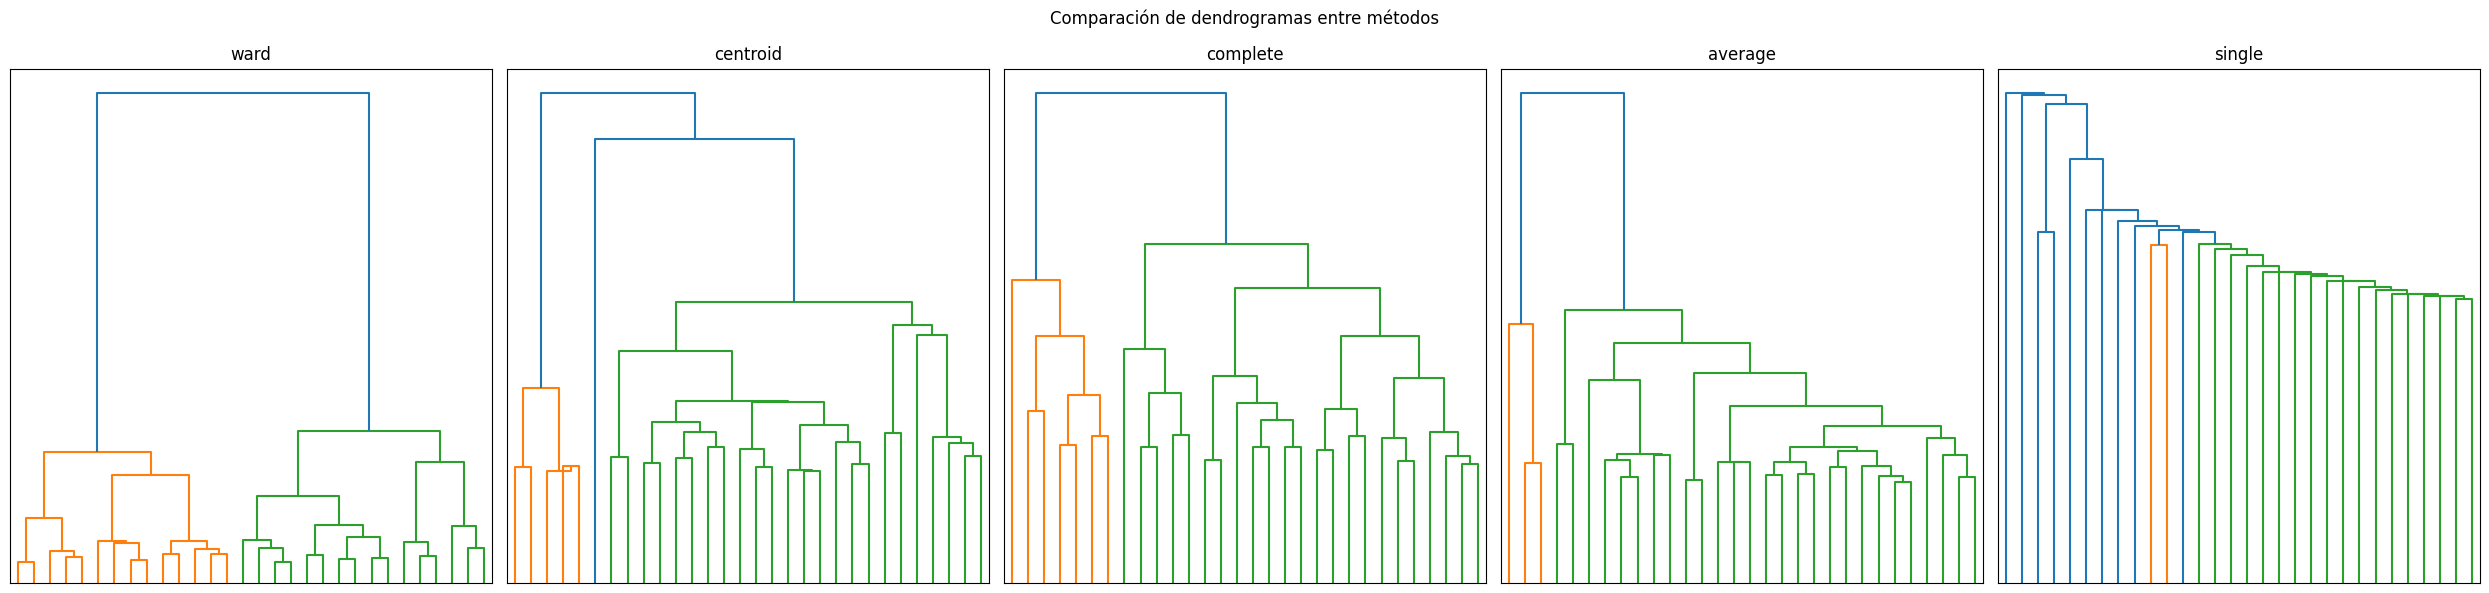

In [ ]:
fig, axes = plt.subplots(1, len(linkage_methods), figsize=(5 * len(linkage_methods), 6))

if len(linkage_methods) == 1:
    axes = [axes]

for ax, method in zip(axes, linkage_methods):
    Z = linkage(X, method=method)
    dendrogram(Z, ax=ax, no_labels=True, p=30, truncate_mode="lastp")
    ax.set_title(method)
    ax.set_yticks([])
    ax.set_xticks([])

plt.suptitle("Comparación de dendrogramas entre métodos")
plt.tight_layout()
plt.show()
